In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import matplotlib.pyplot as plt
import numpy as np
from src import GridWorld, PolicyIteration, ValueIteration, GridWorldVisualizer, ExperimentRunner

In [2]:
# ── Experiment Configuration ──────────────────────────────────────────
# Shared hyperparameters (single source of truth for the entire notebook)
GAMMA = 0.99
THETA = 1e-8

# Dev environment: simple 4x4 grid used for all development/unit testing
def make_dev_env(stochastic=False, **overrides):
    defaults = dict(
        size=4,
        obstacles=[(1, 1)],
        rewards={(3, 3): 1.0},
        default_reward=-1,
        terminal_states=[(3, 3)],
        stochastic=stochastic,
    )
    defaults.update(overrides)
    return GridWorld(**defaults)

# Acceptance environment: larger 8x8 grid for robust validation
def make_acceptance_env(stochastic=False, **overrides):
    defaults = dict(
        size=32,
        obstacles=[(1, 1), (2, 5), (4, 3), (5, 6), (6, 2)],
        rewards={(7, 7): 10.0, (3, 0): -5.0},
        default_reward=-0.04,
        terminal_states=[(7, 7)],
        stochastic=stochastic,
    )
    defaults.update(overrides)
    return GridWorld(**defaults)

env = make_dev_env()
print(f"Dev env: {env.size}x{env.size}, gamma={GAMMA}, theta={THETA}")
acc_env = make_acceptance_env()
print(f"Acceptance env: {acc_env.size}x{acc_env.size}, gamma={GAMMA}, theta={THETA}")

Dev env: 4x4, gamma=0.99, theta=1e-08
Acceptance env: 32x32, gamma=0.99, theta=1e-08


In [3]:
# DONE: Create a custom GridWorld environment (4x4) using Gymnasium's API
# Configurable rewards, obstacles, and transition dynamics

print(f"Grid size: {env.size}x{env.size}")
print(f"States: {env.n_states}, Actions: {env.n_actions}")
print(f"Obstacles: {env.obstacles}")
print(f"Terminal states: {env.terminal_states}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Verify the transition model is built
P = env.get_transition_model()
print(f"\nTransition model entries: {sum(len(P[s]) for s in P)} (s,a) pairs")

# Quick sanity check: from (0,0) moving RIGHT
s = env.rc_to_state(0, 0)
print(f"\nP[state=0, action=RIGHT] = {P[s][env.RIGHT]}")

Grid size: 4x4
States: 16, Actions: 4
Obstacles: {(1, 1)}
Terminal states: {(3, 3)}
Observation space: Discrete(16)
Action space: Discrete(4)

Transition model entries: 64 (s,a) pairs

P[state=0, action=RIGHT] = [(1.0, 1, -1, False)]


In [4]:
# DONE: Make rewards, obstacles, and transition dynamics configurable
env_custom = make_dev_env(
    obstacles=[(1, 1), (2, 2)],
    size=5,
    rewards={(4, 4): 10.0, (0, 4): -5.0},
    terminal_states=[(4, 4)],
)

assert env_custom.size == 5
assert env_custom.obstacles == {(1, 1), (2, 2)}
assert env_custom.reward_map[(4, 4)] == 10.0
assert env_custom.reward_map[(0, 4)] == -5.0
assert env_custom.default_reward == -1
print("Configurable rewards, obstacles, and dynamics: OK")

Configurable rewards, obstacles, and dynamics: OK


In [5]:
# DONE: Include support for stochastic transitions
env_stoch = make_dev_env(stochastic=True, intended_prob=0.5, obstacles=[])

P = env_stoch.get_transition_model()
s = env_stoch.rc_to_state(1, 1)  # interior cell, no boundary effects
transitions = P[s][env_stoch.RIGHT]

# Should have multiple outcomes (intended + perpendicular)
assert len(transitions) > 1, "Stochastic env should have multiple transition outcomes"

# Probabilities must sum to 1
total_prob = sum(t[0] for t in transitions)
assert abs(total_prob - 1.0) < 1e-9, f"Probabilities sum to {total_prob}, expected 1.0"

for prob, s_prime, reward, done in transitions:
    r, c = env_stoch.state_to_rc(s_prime)
    print(f"  P(s'=({r},{c}) | s=(1,1), a=RIGHT) = {prob}")
print("Stochastic transitions: OK")

  P(s'=(1,2) | s=(1,1), a=RIGHT) = 0.5
  P(s'=(0,1) | s=(1,1), a=RIGHT) = 0.25
  P(s'=(2,1) | s=(1,1), a=RIGHT) = 0.25
Stochastic transitions: OK


In [6]:
# DONE: Implement a method to extract or define the full transition model P(s',r|s,a)
P = env.get_transition_model()

assert len(P) == env.n_states, "P should have an entry for every state"
for s in range(env.n_states):
    assert len(P[s]) == env.n_actions, f"State {s} missing actions"
    for a in range(env.n_actions):
        probs = sum(t[0] for t in P[s][a])
        assert abs(probs - 1.0) < 1e-9, f"P[{s}][{a}] probs sum to {probs}"

print(f"Transition model: {env.n_states} states x {env.n_actions} actions, all probabilities valid")
print("Full transition model P(s',r|s,a): OK")

Transition model: 16 states x 4 actions, all probabilities valid
Full transition model P(s',r|s,a): OK


In [7]:
# DONE: Implement policy iteration (synchronous version)
pi = PolicyIteration(env, gamma=GAMMA, theta=THETA)
V_pi, policy_pi = pi.solve(mode="sync")

print(f"Converged in {len(pi.value_history)} policy iteration rounds")
print(f"Eval sweeps per round: {pi.eval_iterations}")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in pi.wall_clock_times]}")

# Display the value function as a grid
V_grid = V_pi.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid = np.array([action_names[a] for a in policy_pi]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid}")

Converged in 8 policy iteration rounds
Eval sweeps per round: [1834, 2, 2, 2, 2, 2, 2]
Wall-clock times: ['0.0139s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s', '0.0001s']

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]


In [8]:
# DONE: Implement policy iteration (in-place version)
pi_inp = PolicyIteration(env, gamma=GAMMA, theta=THETA)
V_inp, policy_inp = pi_inp.solve(mode="inplace")

print(f"Converged in {len(pi_inp.value_history)} policy iteration rounds")
print(f"Eval sweeps per round: {pi_inp.eval_iterations}")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in pi_inp.wall_clock_times]}")

# Display the value function as a grid
V_grid_inp = V_inp.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_inp, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_inp = np.array([action_names[a] for a in policy_inp]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_inp}")

# Verify sync and in-place agree
np.testing.assert_allclose(V_pi, V_inp, atol=1e-6)
np.testing.assert_array_equal(policy_pi, policy_inp)
print("\nSync and in-place values and policies match: OK")

Converged in 8 policy iteration rounds
Eval sweeps per round: [1834, 2, 2, 3, 2, 2, 1]
Wall-clock times: ['0.0128s', '0.0001s', '0.0002s', '0.0001s', '0.0001s', '0.0001s', '0.0001s']

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

Sync and in-place values and policies match: OK


In [9]:
# DONE: Implement value iteration (synchronous version)
vi = ValueIteration(env, gamma=GAMMA, theta=THETA)
V_vi, policy_vi = vi.solve(mode="sync")

print(f"Converged in {vi.iterations} iterations")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in vi.wall_clock_times[:5]]}{'...' if len(vi.wall_clock_times) > 5 else ''}")

# Display the value function as a grid
V_grid_vi = V_vi.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_vi, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_vi = np.array([action_names[a] for a in policy_vi]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_vi}")

# Verify VI and PI agree
np.testing.assert_allclose(V_pi, V_vi, atol=1e-6)
np.testing.assert_array_equal(policy_pi, policy_vi)
print("\nVI sync and PI sync values and policies match: OK")

Converged in 7 iterations
Wall-clock times: ['0.0001s', '0.0000s', '0.0000s', '0.0000s', '0.0000s']...

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

VI sync and PI sync values and policies match: OK


In [10]:
# DONE: Implement value iteration (in-place version)
vi_inp = ValueIteration(env, gamma=GAMMA, theta=THETA)
V_vi_inp, policy_vi_inp = vi_inp.solve(mode="inplace")

print(f"Converged in {vi_inp.iterations} iterations")
print(f"Wall-clock times: {[f'{t:.4f}s' for t in vi_inp.wall_clock_times[:5]]}{'...' if len(vi_inp.wall_clock_times) > 5 else ''}")

# Display the value function as a grid
V_grid_vi_inp = V_vi_inp.reshape(env.size, env.size)
print(f"\nValue function:\n{np.round(V_grid_vi_inp, 3)}")

# Display the policy as action names
action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
policy_grid_vi_inp = np.array([action_names[a] for a in policy_vi_inp]).reshape(env.size, env.size)
print(f"\nPolicy:\n{policy_grid_vi_inp}")

# Verify in-place and sync agree
np.testing.assert_allclose(V_vi, V_vi_inp, atol=1e-6)
np.testing.assert_array_equal(policy_vi, policy_vi_inp)
print("\nVI sync and VI in-place values and policies match: OK")

Converged in 7 iterations
Wall-clock times: ['0.0001s', '0.0000s', '0.0000s', '0.0000s', '0.0000s']...

Value function:
[[-3.95 -2.98 -2.   -1.01]
 [-2.98 -2.   -1.01 -0.01]
 [-2.   -1.01 -0.01  1.  ]
 [-1.01 -0.01  1.    0.  ]]

Policy:
[['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'UP']]

VI sync and VI in-place values and policies match: OK


In [11]:
# DONE: Use NumPy arrays for value functions V(s) and policies π(s)
# Both PolicyIteration and ValueIteration store V and policy as np.ndarray internally.
# Verify the types and shapes returned by each solver.

pi = PolicyIteration(env, gamma=GAMMA, theta=THETA)
V_pi, policy_pi = pi.solve(mode="sync")

vi = ValueIteration(env, gamma=GAMMA, theta=THETA)
V_vi, policy_vi = vi.solve(mode="sync")

for label, V, policy in [("PI", V_pi, policy_pi), ("VI", V_vi, policy_vi)]:
    assert isinstance(V, np.ndarray), f"{label} V is not ndarray"
    assert isinstance(policy, np.ndarray), f"{label} policy is not ndarray"
    assert V.shape == (env.n_states,), f"{label} V shape mismatch"
    assert policy.shape == (env.n_states,), f"{label} policy shape mismatch"
    assert V.dtype == np.float64, f"{label} V dtype mismatch"
    assert policy.dtype == np.int64 or policy.dtype == np.int_, f"{label} policy dtype mismatch"
    print(f"{label}: V {V.dtype}{V.shape}, policy {policy.dtype}{policy.shape}")

# Value history entries are also NumPy arrays
for arr in pi.value_history:
    assert isinstance(arr, np.ndarray)
for arr in vi.value_history:
    assert isinstance(arr, np.ndarray)

print("All value functions and policies are NumPy arrays: OK")

PI: V float64(16,), policy int64(16,)
VI: V float64(16,), policy int64(16,)
All value functions and policies are NumPy arrays: OK


In [12]:
# DONE: Visualize the value function at each iteration as a heatmap (Matplotlib)
viz = GridWorldVisualizer(env)

# Run solver and collect iteration history
vi = ValueIteration(env, gamma=GAMMA, theta=THETA)
V, policy = vi.solve(mode="sync")

# Save a heatmap for each iteration snapshot
for i, V_snap in enumerate(vi.value_history):
    fig, ax = plt.subplots(figsize=(6, 5))
    viz.plot_value_function(V_snap, title=f"Value Function -- iteration {i+1}", ax=ax)
    fig.tight_layout()
    fig.savefig(f"../img/value_function_iter_{i+1:03d}.png", dpi=150)
    plt.close(fig)
    print(f"Saved value_function_iter_{i+1:03d}.png  (max V = {V_snap.max():.4f})")

print(f"\n{len(vi.value_history)} heatmap snapshots written to img/")

Saved value_function_iter_001.png  (max V = 0.0000)
Saved value_function_iter_002.png  (max V = 1.0000)
Saved value_function_iter_003.png  (max V = 1.0000)
Saved value_function_iter_004.png  (max V = 1.0000)
Saved value_function_iter_005.png  (max V = 1.0000)
Saved value_function_iter_006.png  (max V = 1.0000)
Saved value_function_iter_007.png  (max V = 1.0000)
Saved value_function_iter_008.png  (max V = 1.0000)

8 heatmap snapshots written to img/


In [13]:
# DONE: Visualize the policy at each iteration using arrows (quiver plots)
viz = GridWorldVisualizer(env)

# Use PolicyIteration which tracks policy at each round
pi = PolicyIteration(env, gamma=GAMMA, theta=THETA)
V, policy = pi.solve(mode="sync")

# Save a quiver plot for each iteration snapshot
for i, pol_snap in enumerate(pi.policy_history):
    fig, ax = plt.subplots(figsize=(6, 6))
    viz.plot_policy(pol_snap, title=f"Policy -- PI round {i+1}", ax=ax)
    fig.tight_layout()
    fig.savefig(f"../img/policy_iter_{i+1:03d}.png", dpi=150)
    plt.close(fig)
    action_names = ["UP", "RIGHT", "DOWN", "LEFT"]
    unique_actions = set(action_names[a] for a in pol_snap)
    print(f"Saved policy_iter_{i+1:03d}.png  (actions used: {sorted(unique_actions)})")

print(f"\n{len(pi.policy_history)} quiver snapshots written to img/")

Saved policy_iter_001.png  (actions used: ['UP'])
Saved policy_iter_002.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_003.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_004.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_005.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_006.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_007.png  (actions used: ['DOWN', 'RIGHT', 'UP'])
Saved policy_iter_008.png  (actions used: ['DOWN', 'RIGHT', 'UP'])

8 quiver snapshots written to img/


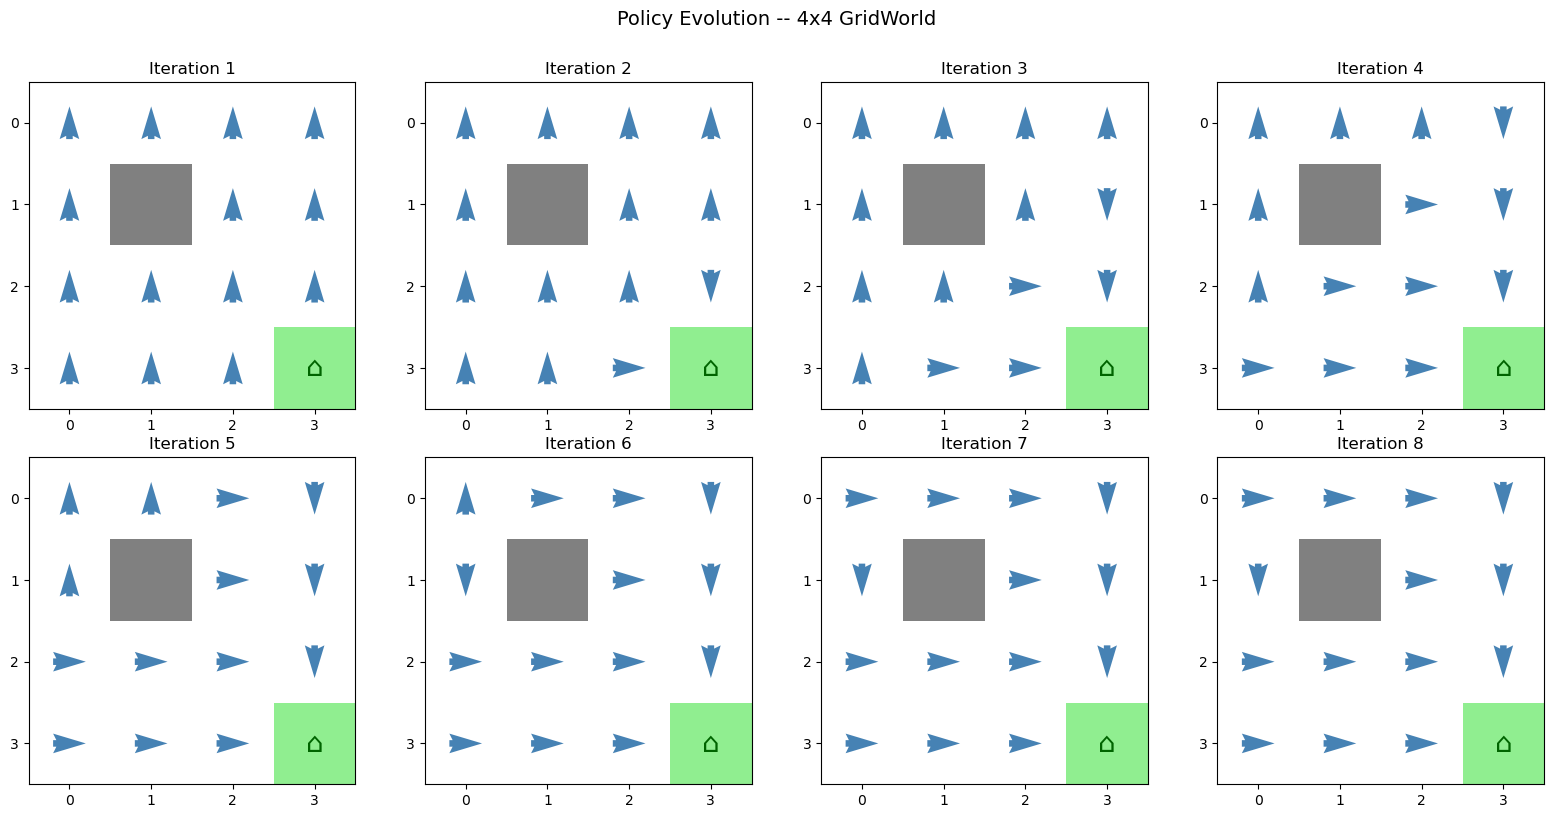

Saved img/policy_contact_sheet.png


In [27]:
# Post-processing: tile quiver plots into a contact sheet
n = len(pi.policy_history)
cols = min(n, 4)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_2d(axes)

viz = GridWorldVisualizer(env)
for i, pol_snap in enumerate(pi.policy_history):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    viz.plot_policy(pol_snap, title=f"Iteration {i + 1}", ax=ax)

# Hide unused subplots
for j in range(n, rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].set_visible(False)

fig.suptitle(f"Policy Evolution -- {env.size}x{env.size} GridWorld", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig("../img/policy_contact_sheet.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved img/policy_contact_sheet.png")

In [28]:
# Post-processing: tile value function PNGs into a contact sheet
from PIL import Image
import glob

paths = sorted(glob.glob("../img/value_function_iter_*.png"))
imgs = [Image.open(p) for p in paths]
n = len(imgs)
cols = min(n, 4)
rows = (n + cols - 1) // cols

w, h = imgs[0].size
sheet = Image.new("RGB", (cols * w, rows * h), "white")

for i, img in enumerate(imgs):
    r, c = divmod(i, cols)
    sheet.paste(img, (c * w, r * h))

sheet.save("../img/value_function_contact_sheet.png")
print(f"Saved img/value_function_contact_sheet.png ({rows}x{cols} grid)")


Saved img/value_function_contact_sheet.png (2x4 grid)


PI sync: 8 snapshots, total time 0.0146s
PI inplace: 8 snapshots, total time 0.0133s


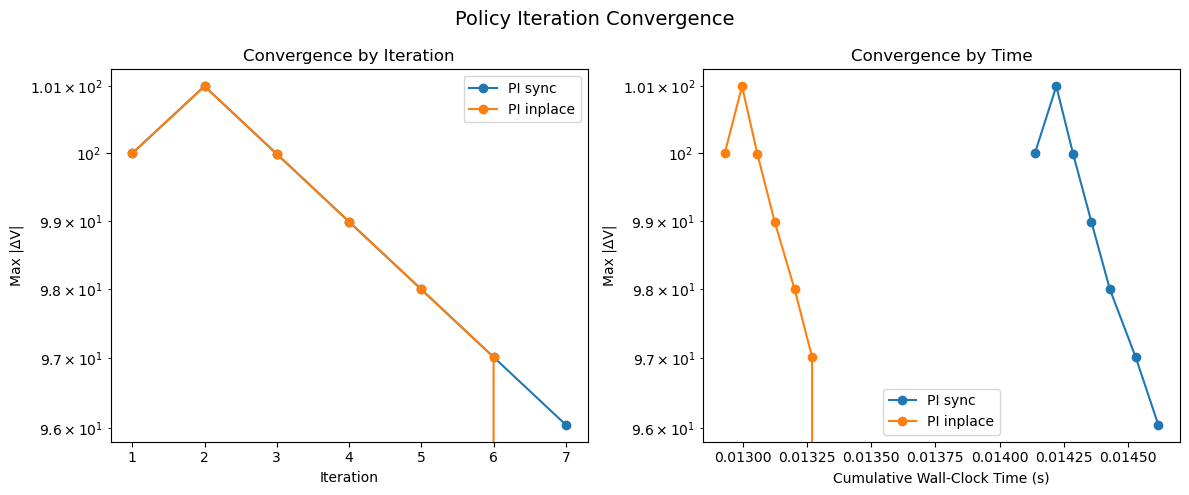

Saved img/convergence_curves_pi.png
VI sync: 8 snapshots, total time 0.0003s
VI inplace: 8 snapshots, total time 0.0003s


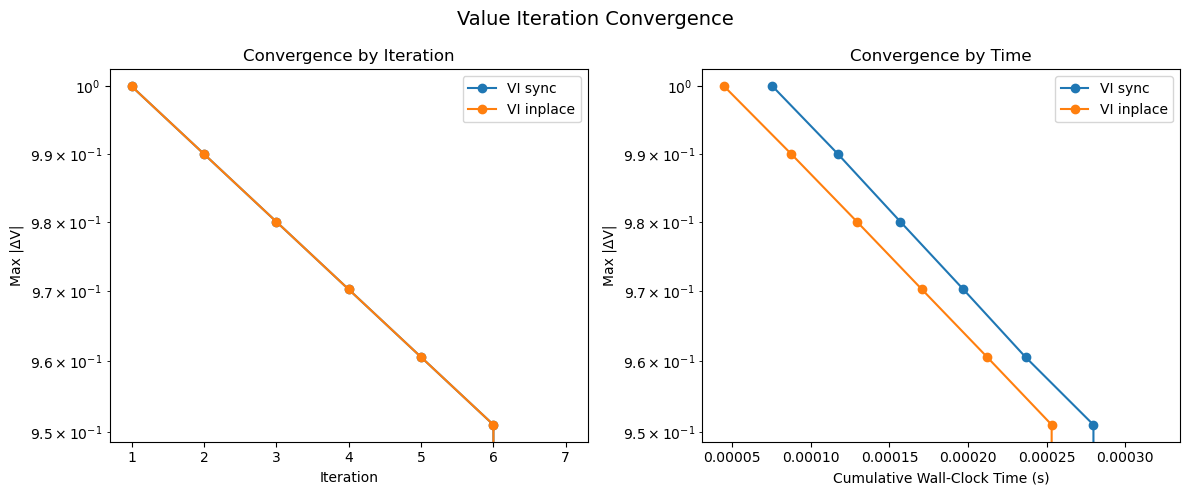

Saved img/convergence_curves_vi.png


In [15]:
# DONE: Visualize convergence curves comparing iteration count and wall-clock time
viz = GridWorldVisualizer(env)

# --- Policy Iteration ---
pi_solvers = {
    "PI sync": PolicyIteration(env, gamma=GAMMA, theta=THETA),
    "PI inplace": PolicyIteration(env, gamma=GAMMA, theta=THETA),
}

pi_results = {}
for label, solver in pi_solvers.items():
    mode = "sync" if "sync" in label else "inplace"
    V, policy = solver.solve(mode=mode)
    pi_results[label] = {
        "value_history": solver.value_history,
        "wall_clock_times": solver.wall_clock_times,
    }
    print(f"{label}: {len(solver.value_history)} snapshots, "
          f"total time {sum(solver.wall_clock_times):.4f}s")

fig_pi = viz.plot_convergence(pi_results, title="Policy Iteration Convergence")
fig_pi.savefig("../img/convergence_curves_pi.png", dpi=150)
plt.show()
print("Saved img/convergence_curves_pi.png")

# --- Value Iteration ---
vi_solvers = {
    "VI sync": ValueIteration(env, gamma=GAMMA, theta=THETA),
    "VI inplace": ValueIteration(env, gamma=GAMMA, theta=THETA),
}

vi_results = {}
for label, solver in vi_solvers.items():
    mode = "sync" if "sync" in label else "inplace"
    V, policy = solver.solve(mode=mode)
    vi_results[label] = {
        "value_history": solver.value_history,
        "wall_clock_times": solver.wall_clock_times,
    }
    print(f"{label}: {len(solver.value_history)} snapshots, "
          f"total time {sum(solver.wall_clock_times):.4f}s")

fig_vi = viz.plot_convergence(vi_results, title="Value Iteration Convergence")
fig_vi.savefig("../img/convergence_curves_vi.png", dpi=150)
plt.show()
print("Saved img/convergence_curves_vi.png")

In [16]:
# DONE: Test on a deterministic GridWorld configuration
env_det = make_acceptance_env(stochastic=False)

print(f"Grid size: {env_det.size}x{env_det.size}")
print(f"States: {env_det.n_states}, Actions: {env_det.n_actions}")
print(f"Obstacles: {env_det.obstacles}")
print(f"Terminal states: {env_det.terminal_states}")

runner = ExperimentRunner(gamma=GAMMA, theta=THETA)
results = runner.run_gridworld("deterministic_8x8", env_det)

action_names = ["UP", "RIGHT", "DOWN", "LEFT"]

for mode, data in results.items():
    V_grid = data["V"].reshape(env_det.size, env_det.size)
    policy_grid = np.array([action_names[a] for a in data["policy"]]).reshape(env_det.size, env_det.size)
    n_iters = len(data["value_history"])
    total_time = sum(data["wall_clock_times"])
    print(f"\n--- {mode} ---")
    print(f"  Iterations: {n_iters}, Total time: {total_time:.4f}s")
    print(f"  Value function:\n{np.round(V_grid, 3)}")
    print(f"  Policy:\n{policy_grid}")

# All four variants should agree on V and policy
policies = [results[m]["policy"] for m in results]
values = [results[m]["V"] for m in results]
for i in range(1, len(values)):
    np.testing.assert_allclose(values[0], values[i], atol=1e-6)
    np.testing.assert_array_equal(policies[0], policies[i])
print("\nAll four variants agree on value function and policy: OK")

Grid size: 32x32
States: 1024, Actions: 4
Obstacles: {(6, 2), (4, 3), (1, 1), (5, 6), (2, 5)}
Terminal states: {(7, 7)}

--- pi_sync ---
  Iterations: 33, Total time: 0.6619s
  Value function:
[[8.285 8.409 8.535 ... 6.566 6.46  6.356]
 [8.409 8.535 8.661 ... 6.673 6.566 6.46 ]
 [8.535 8.661 8.789 ... 6.781 6.673 6.566]
 ...
 [6.566 6.673 6.781 ... 5.087 4.997 4.907]
 [6.46  6.566 6.673 ... 4.997 4.907 4.818]
 [6.356 6.46  6.566 ... 4.907 4.818 4.729]]
  Policy:
[['RIGHT' 'RIGHT' 'RIGHT' ... 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'RIGHT' 'RIGHT' ... 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' ... 'DOWN' 'DOWN' 'DOWN']
 ...
 ['UP' 'UP' 'UP' ... 'UP' 'UP' 'UP']
 ['UP' 'UP' 'UP' ... 'UP' 'UP' 'UP']
 ['UP' 'UP' 'UP' ... 'UP' 'UP' 'UP']]

--- pi_inplace ---
  Iterations: 33, Total time: 0.8301s
  Value function:
[[8.285 8.409 8.535 ... 6.566 6.46  6.356]
 [8.409 8.535 8.661 ... 6.673 6.566 6.46 ]
 [8.535 8.661 8.789 ... 6.781 6.673 6.566]
 ...
 [6.566 6.673 6.781 ... 5.087 4.997 4.907]
 [6.46  

In [17]:
# DONE: Test on a stochastic GridWorld configuration (e.g., 80% intended, 10% perpendicular)
env_stoch_8x8 = make_acceptance_env(stochastic=True, intended_prob=0.8)

print(f"Grid size: {env_stoch_8x8.size}x{env_stoch_8x8.size}")
print(f"States: {env_stoch_8x8.n_states}, Actions: {env_stoch_8x8.n_actions}")
print(f"Obstacles: {env_stoch_8x8.obstacles}")
print(f"Stochastic: {env_stoch_8x8.stochastic}, P(intended)={env_stoch_8x8.intended_prob}")

runner = ExperimentRunner(gamma=GAMMA, theta=THETA)
results_stoch = runner.run_gridworld("stochastic_8x8", env_stoch_8x8)

action_names = ["UP", "RIGHT", "DOWN", "LEFT"]

for mode, data in results_stoch.items():
    V_grid = data["V"].reshape(env_stoch_8x8.size, env_stoch_8x8.size)
    policy_grid = np.array([action_names[a] for a in data["policy"]]).reshape(env_stoch_8x8.size, env_stoch_8x8.size)
    n_iters = len(data["value_history"])
    total_time = sum(data["wall_clock_times"])
    print(f"\n--- {mode} ---")
    print(f"  Iterations: {n_iters}, Total time: {total_time:.4f}s")
    print(f"  Value function:\n{np.round(V_grid, 3)}")
    print(f"  Policy:\n{policy_grid}")

# All four variants should agree on value functions
values = [results_stoch[m]["V"] for m in results_stoch]
for i in range(1, len(values)):
    np.testing.assert_allclose(values[0], values[i], atol=1e-6)
print("\nAll four variants agree on value function: OK")

# Stochastic values should differ from the deterministic case
results_det = runner.results.get("deterministic_8x8")
if results_det is not None:
    det_V = results_det["vi_sync"]["V"]
    stoch_V = results_stoch["vi_sync"]["V"]
    assert not np.allclose(det_V, stoch_V, atol=1e-3)
    print("Stochastic values differ from deterministic: OK (uncertainty lowers values)")

Grid size: 32x32
States: 1024, Actions: 4
Obstacles: {(6, 2), (4, 3), (1, 1), (5, 6), (2, 5)}
Stochastic: True, P(intended)=0.8

--- pi_sync ---
  Iterations: 17, Total time: 3.5272s
  Value function:
[[7.832 8.    8.152 ... 5.959 5.84  5.723]
 [7.685 8.145 8.297 ... 6.004 5.883 5.764]
 [7.622 8.297 8.435 ... 6.083 5.96  5.838]
 ...
 [5.958 6.003 6.082 ... 4.145 4.075 4.036]
 [5.839 5.882 5.959 ... 4.075 3.981 3.94 ]
 [5.722 5.763 5.837 ... 4.036 3.94  3.852]]
  Policy:
[['RIGHT' 'RIGHT' 'RIGHT' ... 'LEFT' 'LEFT' 'LEFT']
 ['UP' 'RIGHT' 'DOWN' ... 'LEFT' 'LEFT' 'LEFT']
 ['UP' 'RIGHT' 'RIGHT' ... 'LEFT' 'LEFT' 'LEFT']
 ...
 ['UP' 'UP' 'UP' ... 'UP' 'UP' 'UP']
 ['UP' 'UP' 'UP' ... 'LEFT' 'UP' 'UP']
 ['UP' 'UP' 'UP' ... 'LEFT' 'LEFT' 'UP']]

--- pi_inplace ---
  Iterations: 19, Total time: 1.5381s
  Value function:
[[7.832 8.    8.152 ... 5.959 5.84  5.723]
 [7.685 8.145 8.297 ... 6.004 5.883 5.764]
 [7.622 8.297 8.435 ... 6.083 5.96  5.838]
 ...
 [5.958 6.003 6.082 ... 4.145 4.075 4.036]


In [18]:
# DONE: Apply DP implementations to Gymnasium's FrozenLake-v1 using its transition dynamics

runner = ExperimentRunner(gamma=GAMMA, theta=THETA)

# Slippery (stochastic) FrozenLake
fl_slippery = runner.run_frozen_lake(map_name="8x8", is_slippery=True)
print("=== FrozenLake 8x8 (slippery) ===")
for variant, data in fl_slippery.items():
    print(f"  {variant}: {len(data['value_history'])} iterations")

# Deterministic FrozenLake
fl_deterministic = runner.run_frozen_lake(map_name="8x8", is_slippery=False)
print("\n=== FrozenLake 8x8 (deterministic) ===")
for variant, data in fl_deterministic.items():
    print(f"  {variant}: {len(data['value_history'])} iterations")

=== FrozenLake 8x8 (slippery) ===
  pi_sync: 12 iterations
  pi_inplace: 13 iterations
  vi_sync: 517 iterations
  vi_inplace: 348 iterations

=== FrozenLake 8x8 (deterministic) ===
  pi_sync: 16 iterations
  pi_inplace: 16 iterations
  vi_sync: 16 iterations
  vi_inplace: 16 iterations


In [19]:
# TODO: Compare in-place Policy Iteration vs in-place Value Iteration
# across deterministic GridWorld environments of increasing size.

runner = ExperimentRunner(gamma=GAMMA, theta=THETA)

sizes = [4, 8, 16, 32, 64]
modes = ["pi_sync","pi_inplace", "vi_sync", "vi_inplace"]

for sz in sizes:
    env_sz = GridWorld(
        size=sz,
        rewards={(sz - 1, sz - 1): 1.0},
        default_reward=-0.04,
        terminal_states=[(sz - 1, sz - 1)],
        stochastic=False,
    )
    runner.run_gridworld(f"det_{sz}x{sz}", env_sz, modes=modes)

# --- Convergence summary table ---
table = runner.compare_convergence()

header = f"{'Experiment':<16} {'Variant':<14} {'Iterations':>10} {'Wall Clock (s)':>14}"
print(header)
print("-" * len(header))
for row in table:
    print(f"{row['experiment']:<16} {row['variant']:<14} {row['iterations']:>10} {row['wall_clock_s']:>14.6f}")

Experiment       Variant        Iterations Wall Clock (s)
---------------------------------------------------------
det_4x4          pi_sync                 7       0.012491
det_4x4          pi_inplace              7       0.010754
det_4x4          vi_sync                 7       0.000318
det_4x4          vi_inplace              7       0.000292
det_8x8          pi_sync                15       0.038720
det_8x8          pi_inplace             15       0.044019
det_8x8          vi_sync                15       0.002521
det_8x8          vi_inplace             15       0.002685
det_16x16        pi_sync                31       0.155604
det_16x16        pi_inplace             31       0.193316
det_16x16        vi_sync                31       0.021030
det_16x16        vi_inplace             31       0.022739
det_32x32        pi_sync                63       0.716384
det_32x32        pi_inplace             63       0.891634
det_32x32        vi_sync                63       0.169215
det_32x32     

In [20]:
# TODO: Repeat the comparison for stochastic environments (80/10/10 transitions)

runner_stoch = ExperimentRunner(gamma=GAMMA, theta=THETA)

sizes = [4, 8, 16, 32, 64]
modes = ["pi_sync","pi_inplace", "vi_sync", "vi_inplace"]

for sz in sizes:
    env_sz = GridWorld(
        size=sz,
        rewards={(sz - 1, sz - 1): 1.0},
        default_reward=-0.04,
        terminal_states=[(sz - 1, sz - 1)],
        stochastic=True,
        intended_prob=0.8,
    )
    runner_stoch.run_gridworld(f"stoch_{sz}x{sz}", env_sz, modes=modes)

# --- Convergence summary table ---
table_stoch = runner_stoch.compare_convergence()

header = f"{'Experiment':<18} {'Variant':<14} {'Iterations':>10} {'Wall Clock (s)':>14}"
print(header)
print("-" * len(header))
for row in table_stoch:
    print(f"{row['experiment']:<18} {row['variant']:<14} {row['iterations']:>10} {row['wall_clock_s']:>14.6f}")

Experiment         Variant        Iterations Wall Clock (s)
-----------------------------------------------------------
stoch_4x4          pi_sync                 6       0.027414
stoch_4x4          pi_inplace              6       0.025021
stoch_4x4          vi_sync                35       0.002920
stoch_4x4          vi_inplace             23       0.001501
stoch_8x8          pi_sync                 8       0.114953
stoch_8x8          pi_inplace             11       0.112745
stoch_8x8          vi_sync                50       0.014445
stoch_8x8          vi_inplace             34       0.010157
stoch_16x16        pi_sync                13       0.810109
stoch_16x16        pi_inplace             23       0.536138
stoch_16x16        vi_sync                75       0.085116
stoch_16x16        vi_inplace             55       0.064623
stoch_32x32        pi_sync                19       2.089636
stoch_32x32        pi_inplace             19       2.349139
stoch_32x32        vi_sync              

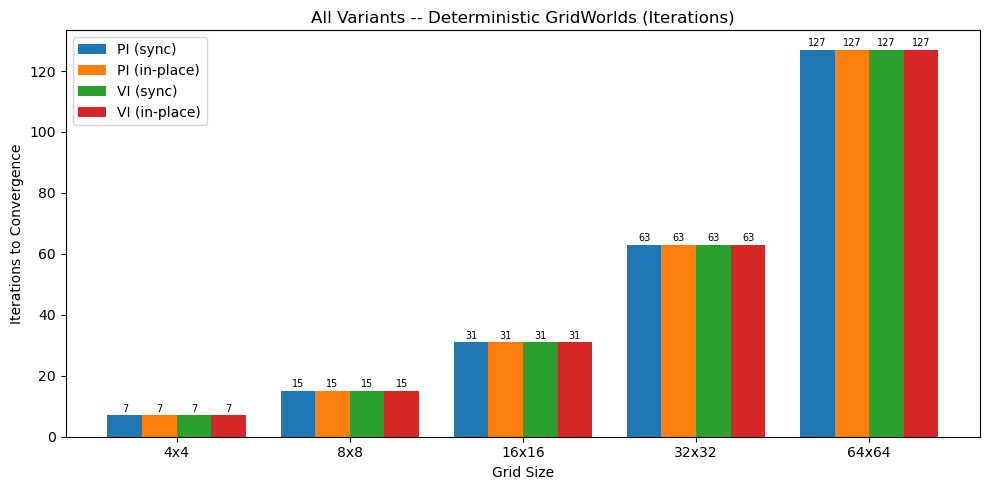

In [21]:
# TODO: Combined iterations -- all variants, deterministic
import matplotlib.pyplot as plt
import numpy as np

sizes = [4, 8, 16, 32, 64]
labels = [f"{sz}x{sz}" for sz in sizes]
x = np.arange(len(sizes))
width = 0.2

variants = [
    ("PI (sync)",     "pi_sync"),
    ("PI (in-place)", "pi_inplace"),
    ("VI (sync)",     "vi_sync"),
    ("VI (in-place)", "vi_inplace"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (label, variant) in enumerate(variants):
    iters = [
        next(r["iterations"] for r in table
             if r["experiment"] == f"det_{sz}x{sz}" and r["variant"] == variant)
        for sz in sizes
    ]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, iters, width, label=label)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                str(int(h)), ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Grid Size")
ax.set_ylabel("Iterations to Convergence")
ax.set_title("All Variants -- Deterministic GridWorlds (Iterations)")
ax.legend()
fig.tight_layout()
fig.savefig("../img/all_variants_iterations_deterministic.png", dpi=150)
plt.show()

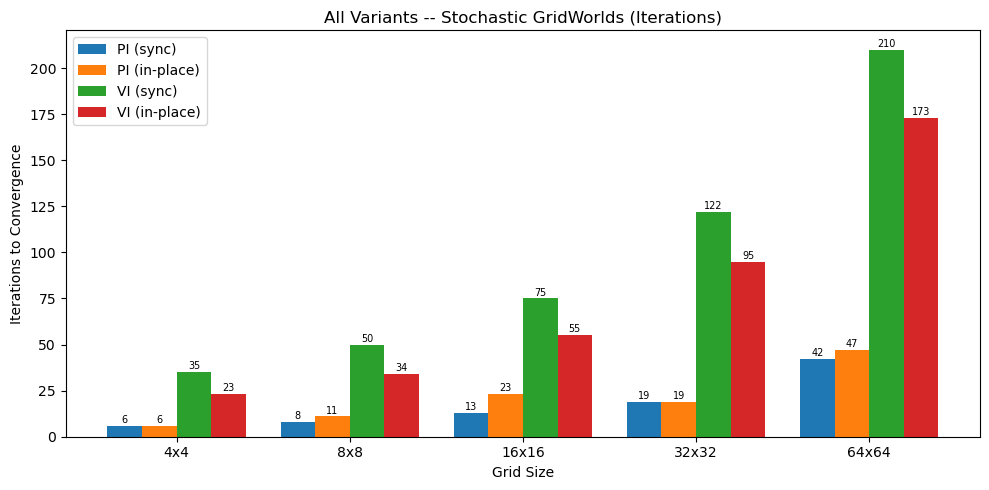

In [22]:
# TODO: Combined iterations -- all variants, stochastic
import matplotlib.pyplot as plt
import numpy as np

sizes = [4, 8, 16, 32, 64]
labels = [f"{sz}x{sz}" for sz in sizes]
x = np.arange(len(sizes))
width = 0.2

variants = [
    ("PI (sync)",     "pi_sync"),
    ("PI (in-place)", "pi_inplace"),
    ("VI (sync)",     "vi_sync"),
    ("VI (in-place)", "vi_inplace"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (label, variant) in enumerate(variants):
    iters = [
        next(r["iterations"] for r in table_stoch
             if r["experiment"] == f"stoch_{sz}x{sz}" and r["variant"] == variant)
        for sz in sizes
    ]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, iters, width, label=label)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                str(int(h)), ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Grid Size")
ax.set_ylabel("Iterations to Convergence")
ax.set_title("All Variants -- Stochastic GridWorlds (Iterations)")
ax.legend()
fig.tight_layout()
fig.savefig("../img/all_variants_iterations_stochastic.png", dpi=150)
plt.show()

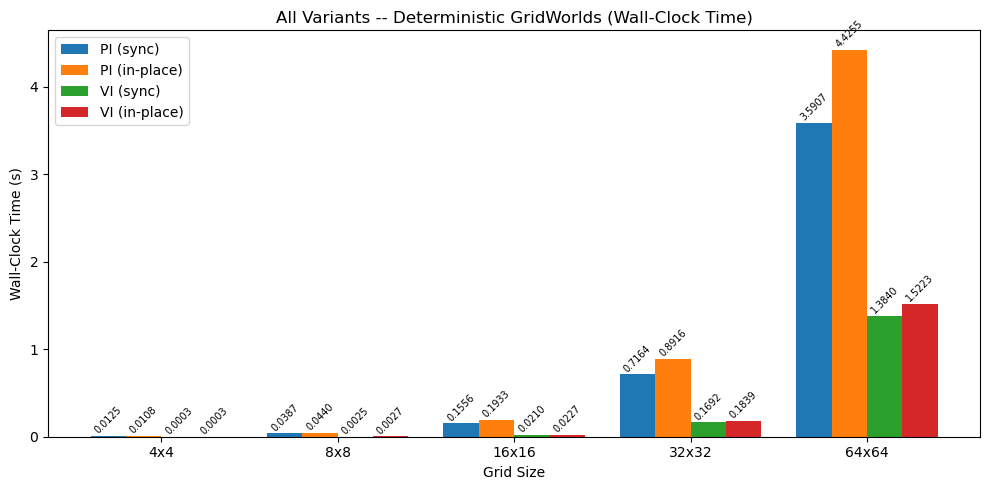

In [23]:
# TODO: Combined wall-clock -- all variants, deterministic
import matplotlib.pyplot as plt
import numpy as np

sizes = [4, 8, 16, 32, 64]
labels = [f"{sz}x{sz}" for sz in sizes]
x = np.arange(len(sizes))
width = 0.2

variants = [
    ("PI (sync)",     "pi_sync"),
    ("PI (in-place)", "pi_inplace"),
    ("VI (sync)",     "vi_sync"),
    ("VI (in-place)", "vi_inplace"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (label, variant) in enumerate(variants):
    times = [
        next(r["wall_clock_s"] for r in table
             if r["experiment"] == f"det_{sz}x{sz}" and r["variant"] == variant)
        for sz in sizes
    ]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, times, width, label=label)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f"{h:.4f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Grid Size")
ax.set_ylabel("Wall-Clock Time (s)")
ax.set_title("All Variants -- Deterministic GridWorlds (Wall-Clock Time)")
ax.legend()
fig.tight_layout()
fig.savefig("../img/all_variants_wallclock_deterministic.png", dpi=150)
plt.show()

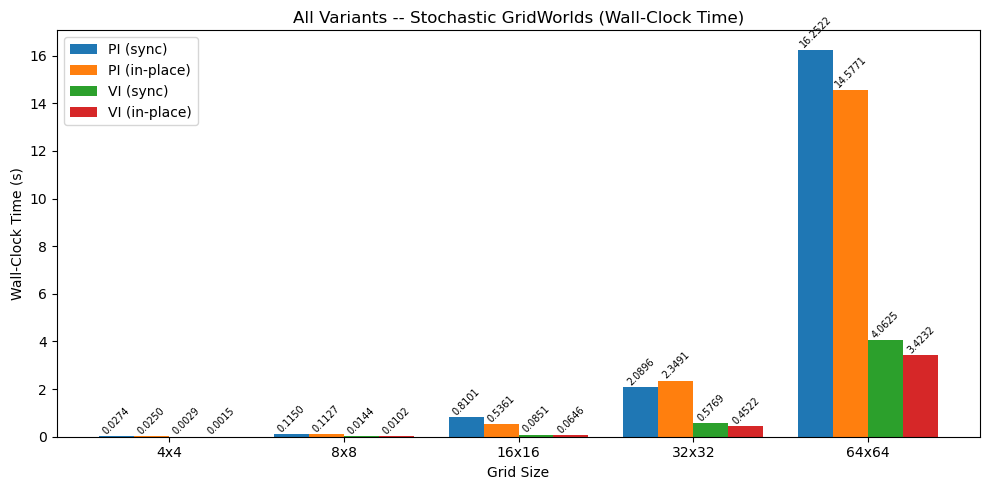

In [24]:
# TODO: Combined wall-clock -- all variants, stochastic
import matplotlib.pyplot as plt
import numpy as np

sizes = [4, 8, 16, 32, 64]
labels = [f"{sz}x{sz}" for sz in sizes]
x = np.arange(len(sizes))
width = 0.2

variants = [
    ("PI (sync)",     "pi_sync"),
    ("PI (in-place)", "pi_inplace"),
    ("VI (sync)",     "vi_sync"),
    ("VI (in-place)", "vi_inplace"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (label, variant) in enumerate(variants):
    times = [
        next(r["wall_clock_s"] for r in table_stoch
             if r["experiment"] == f"stoch_{sz}x{sz}" and r["variant"] == variant)
        for sz in sizes
    ]
    offset = (idx - 1.5) * width
    bars = ax.bar(x + offset, times, width, label=label)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f"{h:.4f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Grid Size")
ax.set_ylabel("Wall-Clock Time (s)")
ax.set_title("All Variants -- Stochastic GridWorlds (Wall-Clock Time)")
ax.legend()
fig.tight_layout()
fig.savefig("../img/all_variants_wallclock_stochastic.png", dpi=150)
plt.show()